# Notebook 01 — POD Basis Construction

 Global POD basis $V_n \in \mathbb{R}^{N \times n}$ from all training trajectories.  
*reference:* Peherstorfer & Willcox (2016)

---


The POD basis is constructed from the matrix of **concatenated initial conditions and trajectories** across all $M$ training parameters:

$$\left[ x_0(\mu_1) \; X(\mu_1)^T \; \Big| \; x_0(\mu_2) \; X(\mu_2)^T \; \Big| \; \cdots \; \Big| \; x_0(\mu_M) \; X(\mu_M)^T \right] \in \mathbb{R}^{N \times (KM+M)}$$

The POD basis vectors $v_1, \ldots, v_n$ are the **left singular vectors** of this matrix, ordered by descending singular value. They are the columns of:

$$V_n = [v_1, \ldots, v_n] \in \mathbb{R}^{N \times n}$$

---


We work with **drawdown** rather than absolute pressure:

$$\Delta p(t) = p(t) - p_{\text{init}}, \quad p_{\text{init}} = 4500 \text{ psia}$$

This ensures the initial condition $\Delta p_0 = 0$ everywhere and all POD modes capture dynamic variation only. The absolute pressure is recovered at any time as $p = p_{\text{init}} + V_n \tilde{x}$.

---

## Output

| File | Content |
|---|---|
| `rom/basis/Vn.npy` | POD basis matrix $[N \times n]$ |
| `rom/basis/singular_values.npy` | All singular values |
| `rom/basis/p_mean.npy` | Scalar $p_{\text{init}}$ (4500 psia) |
| `rom/basis/basis_metadata.json` | n, projection error, training cases used |

---
## 0. Imports and paths

In [1]:
import json
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

TRAINING_DIR = Path('../data/01_training_CO')
BASIS_DIR    = Path('../rom/basis_CO')
BASIS_DIR.mkdir(parents=True, exist_ok=True)

P_INIT  = 4500.0
N_CELLS = 2500
K_GRID  = [5, 10, 20, 50, 100, 200, 500]
S_GRID  = [0, 2, 5, 8, 10, 12, 15]

print(f'Training dir : {TRAINING_DIR.resolve()}')
print(f'Basis dir    : {BASIS_DIR.resolve()}')

Training dir : F:\Niloy Deb\Part Two\reservoir_rom_CO\data\01_training_CO
Basis dir    : F:\Niloy Deb\Part Two\reservoir_rom_CO\rom\basis_CO


---
## 1. Load all training snapshots

For each training parameter point $(k_i, S_j)$ we use **schedule 1 only** to build the snapshot matrix. Schedules 2–7 are reserved for the operator inference step (Notebook 02) where diverse inputs are needed to condition the data matrix $D$. Using all schedules here would inflate the SVD matrix unnecessarily without improving basis quality — the dominant spatial modes are determined by the parameter range, not the input shape.

Each snapshot column added to the concatenation matrix:
- $x_0(\mu_i)$  — initial condition (uniform $\Delta p = 0$)
- $X(\mu_i)^T$ — all $K$ state snapshots as columns

In [2]:
def load_snapshots(case_name):
    path = TRAINING_DIR / case_name / 'snapshots_psia.mat'
    try:
        return sio.loadmat(str(path), variable_names=['X_psia'])['X_psia']
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            return f['X_psia'][()].T


snapshot_cols = []
cases_used    = []
missing       = []

for k in K_GRID:
    for s in S_GRID:
        name = f'k{k:03d}_s{s:02d}_sched1'
        try:
            X = load_snapshots(name)          # [N, K]
            assert X.shape[0] == N_CELLS, f'Wrong row count: {X.shape}'

            dX   = X - P_INIT                 # drawdown [N, K]
            x0   = dX[:, [0]]                 # initial condition column [N, 1]
            snapshot_cols.append(x0)
            snapshot_cols.append(dX)
            cases_used.append(name)
        except FileNotFoundError:
            missing.append(name)

if missing:
    print(f'WARNING: {len(missing)} cases not found — {missing[:5]}')

Z = np.hstack(snapshot_cols)   # [N, sum(K+1)] — the full concatenation matrix
print(f'Cases used          : {len(cases_used)}')
print(f'Concatenation matrix: {Z.shape}  (N x total_cols)')
print(f'Memory              : {Z.nbytes / 1e6:.1f} MB')

Cases used          : 49
Concatenation matrix: (2500, 17199)  (N x total_cols)
Memory              : 344.0 MB


---
## 2. Compute SVD

Linear algebra used `np.linalg.svd` with `full_matrices=False` (economy SVD), which returns:

$$Z = U \Sigma V^T, \quad U \in \mathbb{R}^{N \times r}, \quad r = \min(N, \text{cols})$$

The POD basis vectors are the **columns of $U$**, ordered by descending singular value. The singular values $\sigma_1 \geq \sigma_2 \geq \cdots$ measure the energy captured by each mode.

In [3]:
print('Computing SVD...')
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f'U shape     : {U.shape}')
print(f'Sigma length: {len(sigma)}')
print(f'sigma[0]    : {sigma[0]:.4f}')
print(f'sigma[9]    : {sigma[9]:.6f}')
print(f'sigma[-1]   : {sigma[-1]:.2e}')

Computing SVD...
U shape     : (2500, 2500)
Sigma length: 2500
sigma[0]    : 171545.4254
sigma[9]    : 88.936887
sigma[-1]   : 1.92e-13


---
## 3. The number of modes $n$

Two criteria:

**Cumulative energy** — the fraction of variance captured by the first $n$ modes:
$$E_n = \frac{\sum_{i=1}^n \sigma_i^2}{\sum_{i=1}^r \sigma_i^2}$$

**Projection error** — the mean relative error when reconstructing all training trajectories through the $n$-dimensional subspace (Eq. 29 in the paper):
$$\varepsilon_n = \frac{1}{M} \sum_{i=1}^M \frac{\| X(\mu_i) - X(\mu_i) V_n V_n^T \|_F^2}{\| X(\mu_i) \|_F^2}$$

The paper targets a projection error of $\approx 10^{-5}$ (Section 4.1). We target $\leq 10^{-4}$ to balance accuracy against the condition number of the data matrix $D$ in Notebook 02 — more modes increases $n+1$ columns in $D$, which can worsen conditioning.

In [4]:
cumulative_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
n_modes_range     = np.arange(1, min(51, len(sigma)+1))

proj_errors = []
for n_try in n_modes_range:                      # renamed loop var
    Vn_try = U[:, :n_try]                        # temp variable, not Vn
    err_n  = 0.0
    for k in K_GRID:
        for s in S_GRID:
            name = f'k{k:03d}_s{s:02d}_sched1'
            try:
                X  = load_snapshots(name) - P_INIT
                Xr = Vn_try @ (Vn_try.T @ X)
                err_n += (np.linalg.norm(X - Xr, 'fro')**2 /
                          np.linalg.norm(X, 'fro')**2)
            except FileNotFoundError:
                pass
    proj_errors.append(err_n / len(cases_used))

proj_errors = np.array(proj_errors)

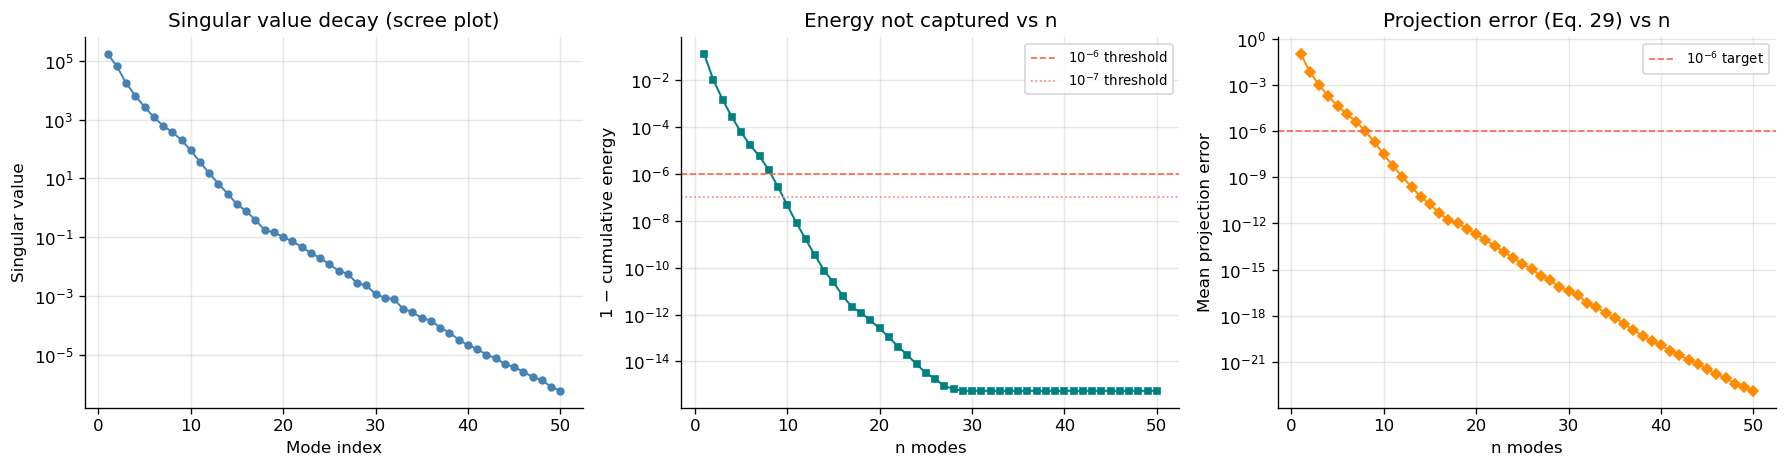

Modes for proj error < 1e-6 : n = 9
Modes for proj error < 1e-7 : n = 10


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(n_modes_range, sigma[:len(n_modes_range)], 'o-',
                 color='steelblue', ms=4, lw=1.2)
axes[0].set_xlabel('Mode index')
axes[0].set_ylabel('Singular value')
axes[0].set_title('Singular value decay (scree plot)')

axes[1].semilogy(n_modes_range,
                 1 - cumulative_energy[:len(n_modes_range)],
                 's-', color='teal', ms=4, lw=1.2)
axes[1].axhline(1e-6, color='tomato', ls='--', lw=1, label='$10^{-6}$ threshold')
axes[1].axhline(1e-7, color='salmon', ls=':', lw=1, label='$10^{-7}$ threshold')
axes[1].set_xlabel('n modes')
axes[1].set_ylabel('1 − cumulative energy')
axes[1].set_title('Energy not captured vs n')
axes[1].legend(fontsize=8)

axes[2].semilogy(n_modes_range, proj_errors, 'D-',
                 color='darkorange', ms=4, lw=1.2)
axes[2].axhline(1e-6, color='tomato', ls='--', lw=1, label='$10^{-6}$ target')
axes[2].set_xlabel('n modes')
axes[2].set_ylabel('Mean projection error')
axes[2].set_title('Projection error (Eq. 29) vs n')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

n_1em6 = int(np.argmax(proj_errors < 1e-6)) + 1
n_1em7 = int(np.argmax(proj_errors < 1e-7)) + 1 if np.any(proj_errors < 1e-5) else None
print(f'Modes for proj error < 1e-6 : n = {n_1em6}')
print(f'Modes for proj error < 1e-7 : n = {n_1em7}')

---
## 4. Select $n$ Modes inspection


In [6]:
# Per-case projection error at chosen n

N_MODES = 6    # set explicitly 

Vn = U[:, :N_MODES]    # THIS is the assignment which is important

per_case_errors = {}
for k in K_GRID:
    for s in S_GRID:
        name = f'k{k:03d}_s{s:02d}_sched1'
        try:
            X   = load_snapshots(name) - P_INIT
            Xr  = Vn @ (Vn.T @ X)
            err = np.linalg.norm(X - Xr, 'fro')**2 / np.linalg.norm(X, 'fro')**2
            per_case_errors[name] = err
        except FileNotFoundError:
            pass

errors = np.array(list(per_case_errors.values()))
print(f'N_MODES : {N_MODES}')
print(f'Vn shape: {Vn.shape}')    # must print (2500, 10)
print(f'Mean    : {errors.mean():.2e}')
print(f'Max     : {errors.max():.2e}')
print(f'Worst   : {max(per_case_errors, key=per_case_errors.get)}')

N_MODES : 6
Vn shape: (2500, 6)
Mean    : 1.30e-05
Max     : 3.66e-05
Worst   : k005_s08_sched1


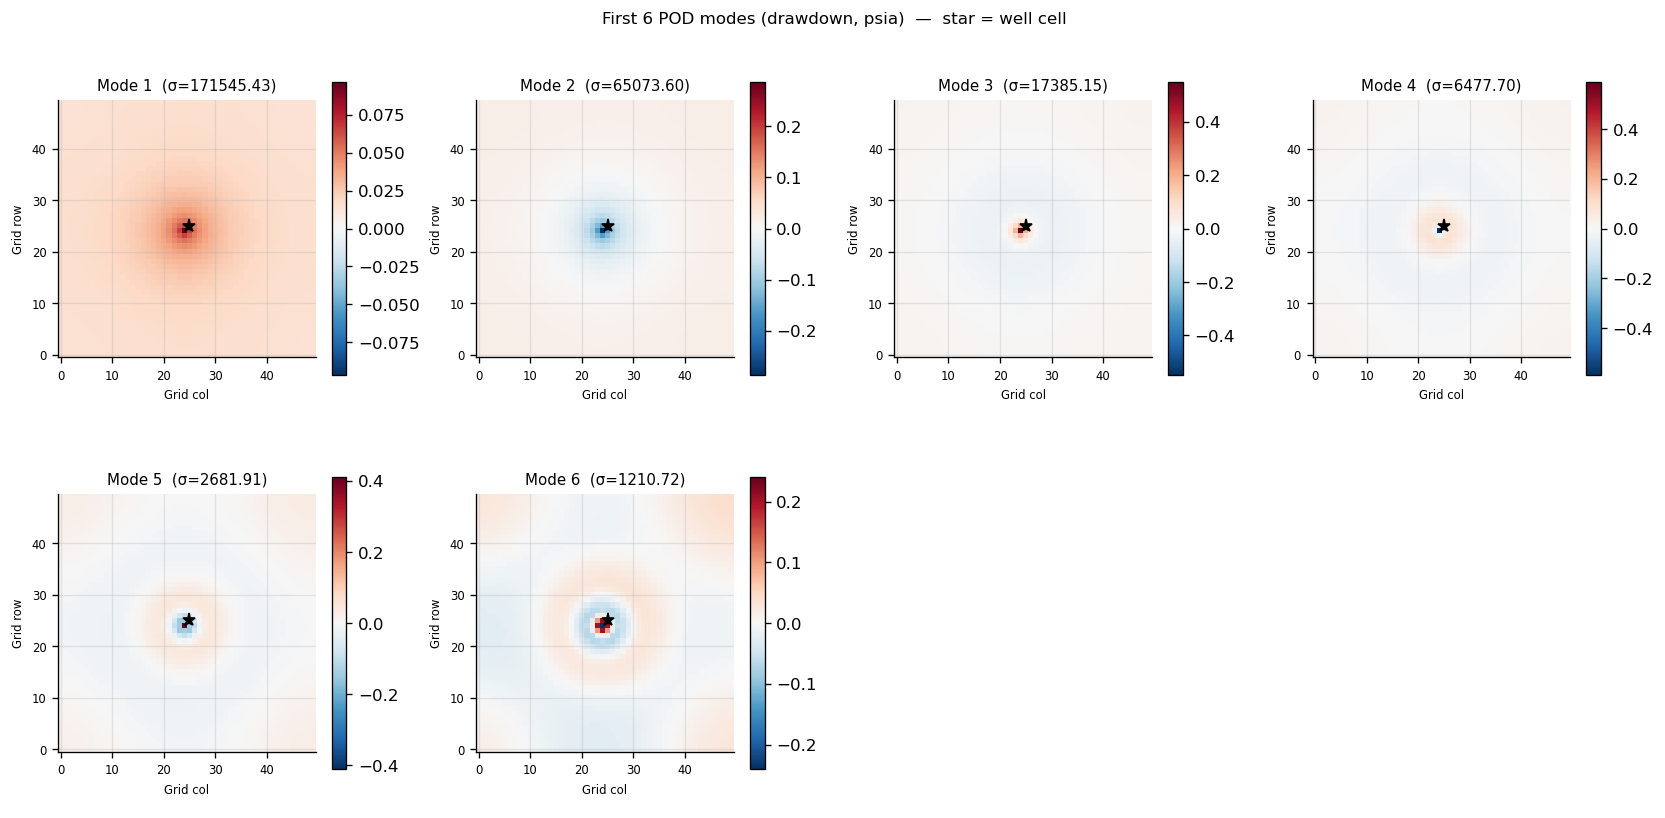

In [7]:
NX, NY  = 50, 50
n_show  = min(N_MODES, 10)
n_cols  = 4
n_rows  = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows))
axes = np.array(axes).ravel()

for i in range(n_show):
    mode_map = Vn[:, i].reshape(NY, NX)
    vmax     = np.abs(mode_map).max()
    im = axes[i].imshow(mode_map, origin='lower', cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax)
    axes[i].set_title(f'Mode {i+1}  (σ={sigma[i]:.2f})', fontsize=9)
    axes[i].set_xlabel('Grid col', fontsize=7)
    axes[i].set_ylabel('Grid row', fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].plot(NY//2, NX//2, 'k*', ms=8)
    plt.colorbar(im, ax=axes[i], shrink=0.8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'First {n_show} POD modes (drawdown, psia)  —  star = well cell',
             fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Orthogonality check

By construction the POD basis is orthonormal: $V_n^T V_n = I_n$. We verify this numerically. The off-diagonal entries of $V_n^T V_n$ should be at machine precision ($\approx 10^{-15}$). Any entry above $10^{-10}$ would indicate a numerical problem in the SVD.

In [8]:
VtV          = Vn.T @ Vn
n_actual     = Vn.shape[1]         

off_diag_max = np.abs(VtV - np.eye(n_actual)).max()
diag_min     = np.diag(VtV).min()

print(f'Vn shape          : {Vn.shape}')
print(f'N_MODES           : {N_MODES}')
print(f'max |VnT Vn - I|  : {off_diag_max:.2e}  (should be ~1e-15)')
print(f'min diagonal entry: {diag_min:.10f}  (should be 1.0)')

if N_MODES != n_actual:
    print(f'Mismatch: N_MODES={N_MODES} but Vn has {n_actual} columns.')
    print('    Re-run Cell 12 to rebuild Vn with the correct truncation.')
elif off_diag_max < 1e-10:
    print('Basis is orthonormal')
else:
    print('Orthogonality check failed — check SVD implementation')

Vn shape          : (2500, 6)
N_MODES           : 6
max |VnT Vn - I|  : 1.78e-15  (should be ~1e-15)
min diagonal entry: 1.0000000000  (should be 1.0)
Basis is orthonormal


---
## 6. Reconstruction spot check

Visual sanity check: reconstruct the pressure field of one held-out time snapshot from a **training case** through the $n$-dimensional subspace and compare with the original. The reconstruction error should be at or below the chosen projection error threshold.

Case            : k050_s02_sched1
Snapshot index  : 175
Relative error  : 3.45e-02


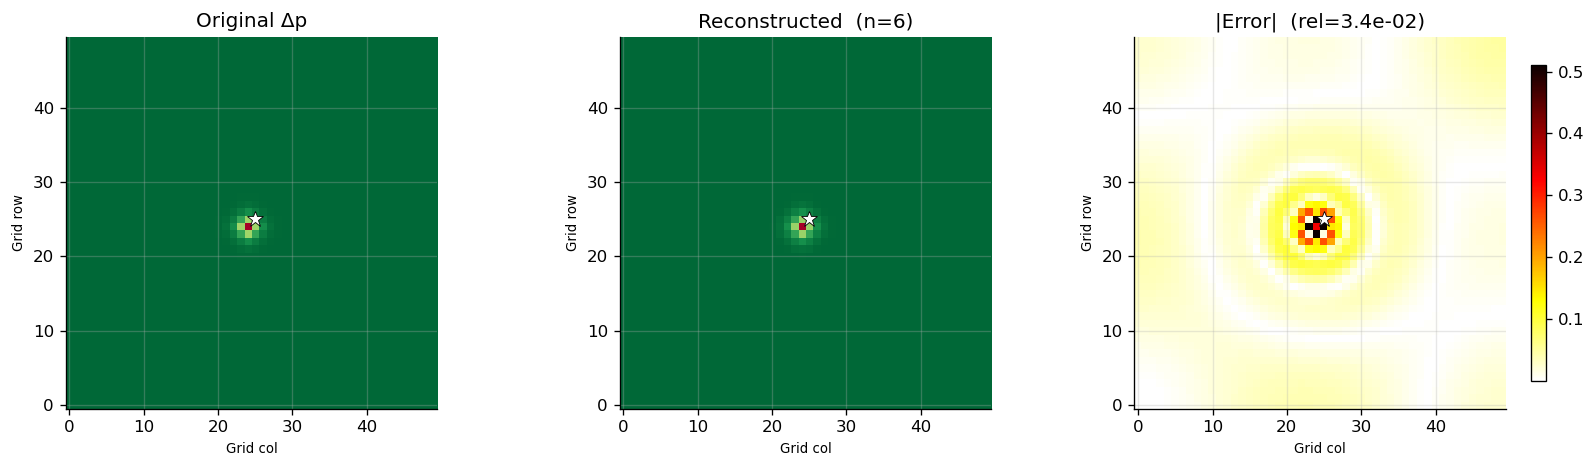

In [9]:
test_case   = 'k050_s02_sched1'
X_full      = load_snapshots(test_case) - P_INIT   # [N, K]
snap_idx    = X_full.shape[1] // 2                  # mid-simulation snapshot

x_orig      = X_full[:, snap_idx]
x_recon     = Vn @ (Vn.T @ x_orig)
x_err       = x_orig - x_recon

rel_err = np.linalg.norm(x_err) / np.linalg.norm(x_orig)
print(f'Case            : {test_case}')
print(f'Snapshot index  : {snap_idx}')
print(f'Relative error  : {rel_err:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmin = min(x_orig.min(), x_recon.min())
vmax = max(x_orig.max(), x_recon.max())

axes[0].imshow(x_orig.reshape(NY, NX), origin='lower',
               cmap='RdYlGn', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Δp')

axes[1].imshow(x_recon.reshape(NY, NX), origin='lower',
               cmap='RdYlGn', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Reconstructed  (n={N_MODES})')

im = axes[2].imshow(np.abs(x_err).reshape(NY, NX),
                    origin='lower', cmap='hot_r')
axes[2].set_title(f'|Error|  (rel={rel_err:.1e})')
plt.colorbar(im, ax=axes[2], shrink=0.85)

for ax in axes:
    ax.plot(NY//2, NX//2, 'w*', ms=10, markeredgecolor='k', markeredgewidth=0.5)
    ax.set_xlabel('Grid col', fontsize=8)
    ax.set_ylabel('Grid row', fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Save basis

Saves the POD basis and metadata to `rom/basis/`. All subsequent notebooks load from this location — do not change the file names.

In [10]:
assert Vn.shape == (N_CELLS, N_MODES), \
    f'Vn shape {Vn.shape} does not match expected ({N_CELLS}, {N_MODES}). Re-run Cell 12.'

np.save(BASIS_DIR / 'Vn.npy',             Vn)
np.save(BASIS_DIR / 'singular_values.npy', sigma)
np.save(BASIS_DIR / 'p_mean.npy',          np.array([P_INIT]))

metadata = {
    'n_modes'          : int(N_MODES),
    'N_cells'          : int(N_CELLS),
    'p_init_psia'      : float(P_INIT),
    'projection_error' : float(proj_errors[N_MODES - 1]),
    'cumulative_energy': float(cumulative_energy[N_MODES - 1]),
    'sigma_n'          : float(sigma[N_MODES - 1]),
    'sigma_1'          : float(sigma[0]),
    'n_training_cases' : len(cases_used),
    'training_cases'   : cases_used,
    'svd_matrix_shape' : list(Z.shape),
}

with open(BASIS_DIR / 'basis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
for p in sorted(BASIS_DIR.iterdir()):
    print(f'  {p.name:<30} {p.stat().st_size / 1e3:.1f} kB')

print(f'\nReady for Notebook 02 — Operator Inference')
print(f'  Vn   : {Vn.shape}')
print(f'  n    : {N_MODES}')
print(f'  error: {proj_errors[N_MODES-1]:.2e}')

Saved:
  basis_metadata.json            1.5 kB
  p_mean.npy                     0.1 kB
  singular_values.npy            20.1 kB
  Vn.npy                         120.1 kB

Ready for Notebook 02 — Operator Inference
  Vn   : (2500, 6)
  n    : 6
  error: 1.30e-05
